In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer
import warnings

warnings.filterwarnings('ignore')

In [14]:
print("Load Dataset...")
df = pd.read_csv('D:\Kuliah\Tugas\semester 6\P. Data mining\MusicGeneratingWithSpotify\spotify_data clean.csv')

print(f"Data berhasil dimuat: {df.shape[0]} Baris dan {df.shape[1]} Kolom")
display(df.head(10))

Load Dataset...
Data berhasil dimuat: 8582 Baris dan 15 Kolom


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39
5,4ccpCcZYseq8VrPMK1EDs0,BLEED,1,2,False,Minzie,46,7218,dark r&b,2NQv9p3ZQW0Ed1LB9enix8,BLEED,2025-10-30,3,single,2.76
6,3QoQ3HqXTAjgEl9LbNMbYp,Te Procuro na Cidade,1,20,False,AZERDK,30,1657,NaN,1PpuOsLjPWshDLxkr0oHeU,Te Procuro na Cidade,2025-10-30,1,single,4.12
7,1YEZbdT417SfolPQzaoHs2,come closer,1,27,False,Rumelis,49,8802,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.53
8,4pZ949nFW5SurwzE0TSe7I,Cupido Vagabundo,1,16,False,Toni dos Anjos,6,475,NaN,60DLQZkzpvDvVfvEC6VOJM,Cupido Vagabundo,2025-10-30,2,single,2.92
9,0L0LgwFZ7UtBnRNQvSBty6,LET’S GO!,1,33,True,PsychoYP,48,154802,"nigerian drill, alté, afro adura, afrobeats, a...",3ARxksm8CspGeAaZZB1v2w,LET’S GO!,2025-10-28,1,single,2.40


In [15]:
print("Cleanng and process the data...")
df.replace('N/A', np.nan, inplace=True)
df.dropna(subset=['artist_genres', 'track_name', 'artist_name'], inplace=True)

# Put genre into mood ategorize
def assign_mood_nlp(genre_text):
    genre = str(genre_text).lower()
    if any(k in genre for k in ['rock', 'metal', 'punk', 'dance', 'electronic', 'house', 'hip hop']):
        return 'Energetic'
    elif any(k in genre for k in ['pop', 'disco', 'country', 'reggae']):
        return 'Happy'
    elif any(k in genre for k in ['jazz', 'lo-fi', 'acoustic', 'r&b', 'chill', 'blues', 'classical']):
        return 'Chill'
    else:
        return 'Sad'

# DataFrame
df['mood'] = df['artist_genres'].apply(assign_mood_nlp)

# Combine genre and song
df['text_feature'] = df['track_name'] + " - Genre: " + df['artist_genres']

print(f"✅ Preprocessing selesai. Total data bersih: {df.shape[0]} Baris.")

Cleanng and process the data...
✅ Preprocessing selesai. Total data bersih: 5221 Baris.


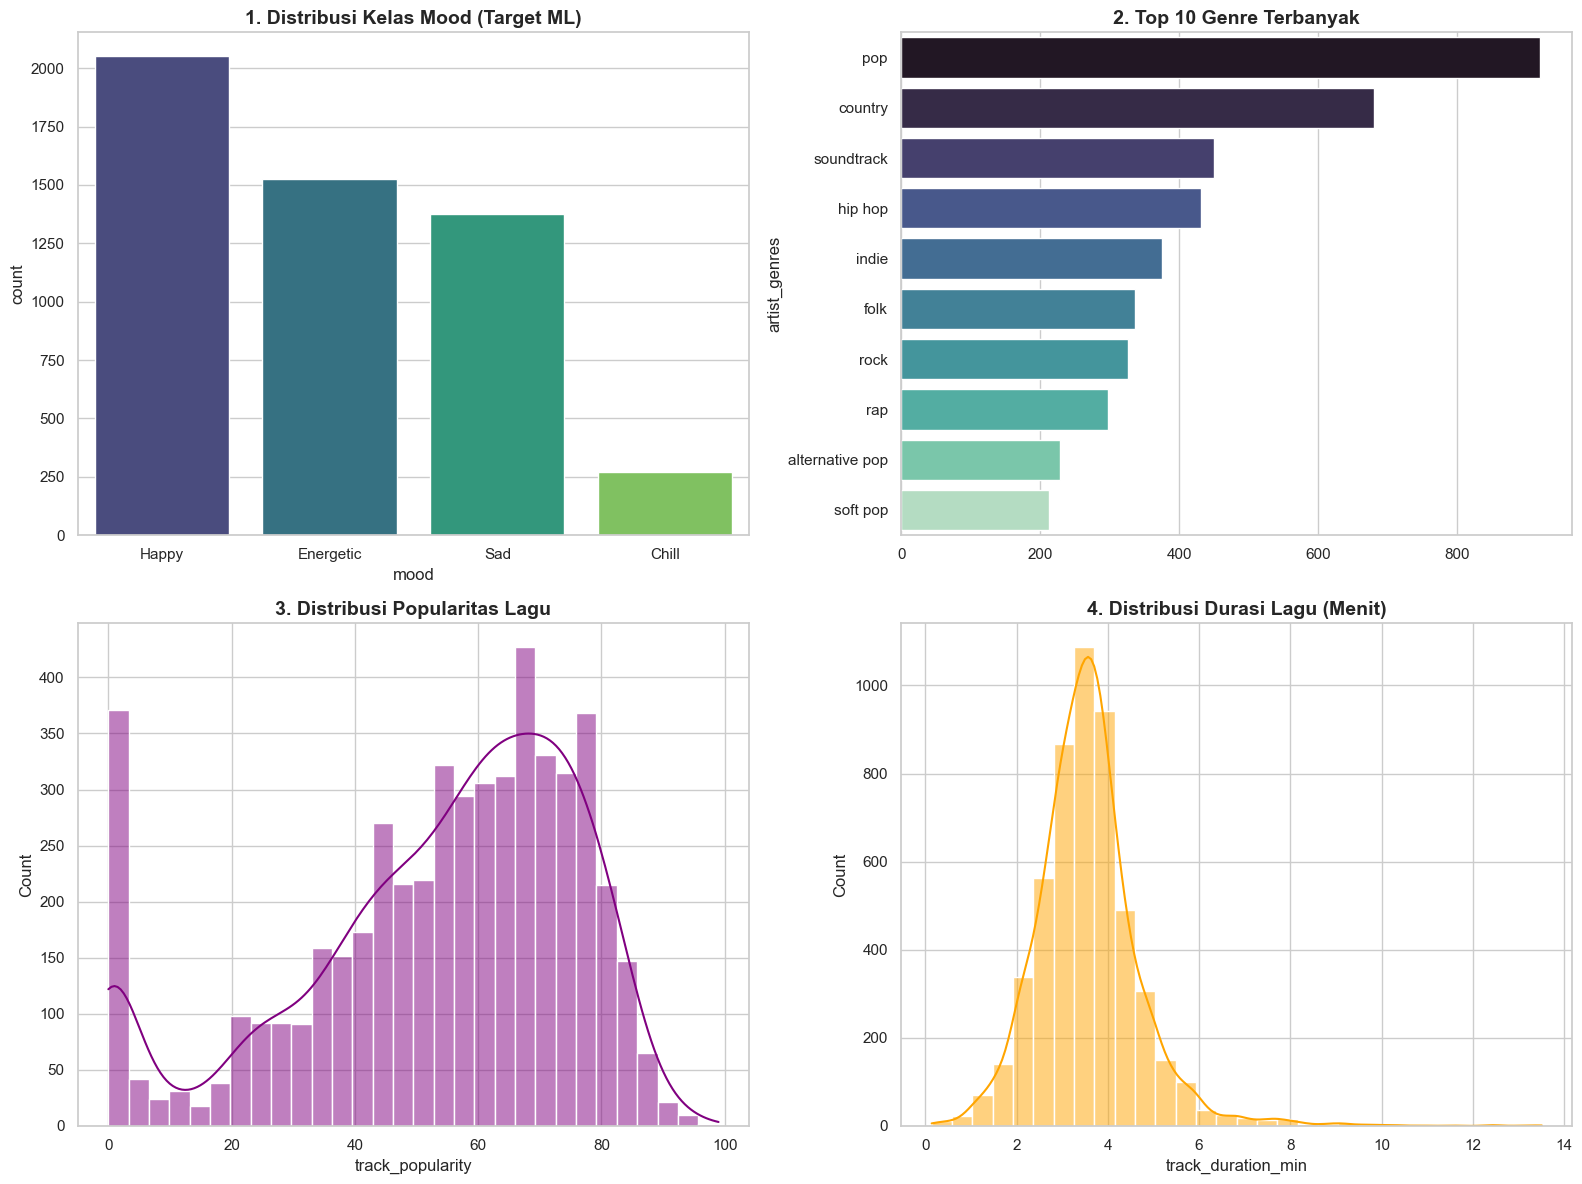

In [16]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Grafic 1: Target Distribution (Mood)
sns.countplot(data=df, x='mood', palette='viridis', order=df['mood'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('1. Distribusi Kelas Mood (Target ML)', fontsize=14, fontweight='bold')

# Grafic 2: Top 10 genre
all_genres = df['artist_genres'].str.split(',').explode().str.strip()
top_genres = all_genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='mako', ax=axes[0, 1])
axes[0, 1].set_title('2. Top 10 Genre Terbanyak', fontsize=14, fontweight='bold')

# Grafik 3: Popularity Distribution
sns.histplot(df['track_popularity'], bins=30, kde=True, color='purple', ax=axes[1, 0])
axes[1, 0].set_title('3. Distribusi Popularitas Lagu', fontsize=14, fontweight='bold')

# Grafik 4: Duration Distribution
sns.histplot(df['track_duration_min'], bins=30, kde=True, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('4. Distribusi Durasi Lagu (Menit)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import pickle

print("--- Membangun Machine Learning Pipeline ---")

# 1. Membuat Custom Transformer (Agar SentenceTransformer bisa masuk Pipeline)
class TextEmbedder(BaseEstimator, TransformerMixin):
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.model_name = model_name
        self.model = None

    def fit(self, X, y=None):
        # Load model hanya saat training dimulai
        if self.model is None:
            self.model = SentenceTransformer(self.model_name)
        return self

    def transform(self, X):
        # Mengubah teks menjadi vektor (Embeddings)
        return self.model.encode(X, show_progress_bar=False)

# Membagi data (80% Train, 20% Test)
df_sample = df.sample(n=2500, random_state=42)
X_text = df_sample['text_feature'].tolist()
y = df_sample['mood']
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# 2. MEMBUAT PIPELINE UTAMA
print("⏳ Merakit Pipeline (Text Embedder -> SVM Classifier)...")
ml_pipeline = Pipeline([
    ('vectorizer', TextEmbedder()),                                # Tahap 1: Ekstraksi Teks ke Vektor
    ('classifier', SVC(kernel='linear', class_weight='balanced'))  # Tahap 2: Klasifikasi SVM
])

# 3. TRAINING SELURUH PIPELINE SEKALIGUS
print("⏳ Melatih Pipeline... (Ini akan memakan waktu sebentar)")
ml_pipeline.fit(X_train_text, y_train)

# 4. EVALUASI
print("\n--- 🎯 Hasil Evaluasi Pipeline ---")
# Karena pakai Pipeline, kita bisa langsung masukkan teks mentah ke .predict()!
y_pred = ml_pipeline.predict(X_test_text)
akurasi = accuracy_score(y_test, y_pred)

print(f"AKURASI MODEL: {akurasi * 100:.2f}%\n")
print("Detail Laporan:")
print(classification_report(y_test, y_pred))

# [OPSIONAL] Simpan Pipeline untuk Production/Website
# with open('music_mood_pipeline.pkl', 'wb') as file:
#     pickle.dump(ml_pipeline, file)
# print("✅ Pipeline berhasil disimpan sebagai 'music_mood_pipeline.pkl'")

--- Membangun Machine Learning Pipeline ---
⏳ Merakit Pipeline (Text Embedder -> SVM Classifier)...
⏳ Melatih Pipeline... (Ini akan memakan waktu sebentar)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


--- 🎯 Hasil Evaluasi Pipeline ---
AKURASI MODEL: 93.80%

Detail Laporan:
              precision    recall  f1-score   support

       Chill       0.92      0.88      0.90        26
   Energetic       0.94      0.91      0.92       143
       Happy       0.97      0.96      0.96       198
         Sad       0.90      0.95      0.92       133

    accuracy                           0.94       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.94      0.94      0.94       500



In [ ]:
# UI: MUSIC GENERATOR
print("--- 🎵 Music Generator UI 🎵 ---")

common_genres = [
    'Pop', 'Rock', 'Hip Hop', 'R&B', 'Country',
    'Jazz', 'Electronic', 'Classical', 'Blues',
    'Indie', 'Metal', 'Reggae', 'Dance'
]
unique_moods = sorted(df['mood'].unique().tolist())

mood_dropdown = widgets.Dropdown(options=['Any'] + unique_moods, value='Any', description='Mood:')
genre_dropdown = widgets.Dropdown(options=['Any'] + common_genres, value='Any', description='Genre:')
generate_button = widgets.Button(description="Generate Music", button_style='success', icon='music')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        selected_genre = genre_dropdown.value
        selected_mood = mood_dropdown.value

        filtered_df = df.copy()

        if selected_genre != 'Any':
            search_term = selected_genre.lower()
            filtered_df = filtered_df[filtered_df['artist_genres'].str.contains(search_term, case=False, na=False)]

        if selected_mood != 'Any':
            filtered_df = filtered_df[filtered_df['mood'] == selected_mood]

        if filtered_df.empty:
            print(f"❌ Tidak ada lagu untuk Genre: {selected_genre} dan Mood: {selected_mood}. Coba kombinasi lain!")
        else:
            print(f"✅ AI merekomendasikan lagu untuk Genre: '{selected_genre}' & Mood: '{selected_mood}'!\n")

            sample_size = min(3, len(filtered_df))
            recommendations = filtered_df.sample(sample_size)

            for idx, row in recommendations.iterrows():
                track_id = row['track_id']
                spotify_player = f"""
                <div style="margin-bottom: 5px;">
                    <iframe src="https://open.spotify.com/embed/track/{track_id}"
                            width="300" height="80" frameborder="0"
                            allowtransparency="true" allow="encrypted-media">
                    </iframe>
                </div>
                """
                display(HTML(spotify_player))

generate_button.on_click(on_button_clicked)
display(mood_dropdown, genre_dropdown, generate_button, output)

--- 🎵 Music Generator UI 🎵 ---


Dropdown(description='Mood:', options=('Any', 'Chill', 'Energetic', 'Happy', 'Sad'), value='Any')

Dropdown(description='Genre:', options=('Any', 'Pop', 'Rock', 'Hip Hop', 'R&B', 'Country', 'Jazz', 'Electronic…

Button(button_style='success', description='Generate Music', icon='music', style=ButtonStyle())

Output()